# Devoir — Apprentissage profond (75 points)

Dans ce devoir, nous construisons un détecteur de séismes : un classificateur qui décide si une fenêtre de 30 secondes de mouvement du sol à 100 Hz (composante verticale) contient un séisme ou seulement du bruit. Les fenêtres proviennent du paquet du cours ``mlgeo_synth`` avec une graine fixée : chaque événement a donc une magnitude, une distance et un rapport signal sur bruit connus ; l'enseignante conserve une variante à graine cachée qui sert à contrôler par sondage les résultats rendus.

C'est la même tâche de détection que le CNN 1-D de la leçon [4.3](mlgeo_4.3_CNN.ipynb), sur un jeu de données neuf et avec une autre famille de modèles. Un MLP n'a aucune invariance par translation : il ne peut pas apprendre qu'un séisme à la 8e seconde et un séisme à la 14e seconde sont la même chose. Nous lui donnons donc le spectre d'amplitude en échelle logarithmique de chaque fenêtre, qui écarte l'instant d'arrivée et conserve le contenu fréquentiel qui sépare les événements (énergie d'ondelette à bande limitée) du bruit (un spectre en loi de puissance). Le chapitre 2.6 a construit cette transformation ; ici, elle justifie son existence.

Nous mettrons en pratique les compétences des leçons 4.1, 4.2 et 4.5 : construire et entraîner un MLP en PyTorch, mener une expérience d'architecture contrôlée, diagnostiquer des entraînements défaillants à partir de leurs courbes, évaluer honnêtement face à une référence, et quantifier l'incertitude avec un petit ensemble profond.

### Importation des bibliothèques

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
%matplotlib inline

## 1. Construire et entraîner un détecteur MLP (20 points)

Nous suivons les étapes suivantes :
* inspecter les données (2 points)
* découpage et mise à l'échelle sans fuite de données (4 points)
* compléter le squelette du modèle (4 points)
* écrire la boucle d'entraînement (8 points)
* courbes d'apprentissage (2 points)

In [2]:
import mlgeo_synth

fs = 100.0  # sampling rate (Hz)
X_wave, y, metas = mlgeo_synth.seismogram_dataset(
    n_events=600, n_noise=600, fs=fs, duration_s=30.0, seed=2026)
print(X_wave.shape, y.shape)

(1200, 3000) (1200,)


Chaque ligne de ``X_wave`` est une fenêtre de 30 s (3 000 échantillons) ; ``y`` vaut 1 pour les fenêtres d'événement et 0 pour les fenêtres de bruit. Pour les fenêtres d'événement, ``metas`` enregistre les vrais temps d'arrivée P et S ainsi que le rapport signal sur bruit.

La cellule ci-dessous calcule l'entrée du modèle : le spectre d'amplitude en échelle logarithmique de chaque fenêtre, restreint à la bande 0,2–30 Hz où vivent à la fois l'énergie de l'ondelette et le bruit. C'est la représentation prête pour l'IA que verra le MLP.

In [3]:
freqs = np.fft.rfftfreq(X_wave.shape[1], d=1/fs)
band = (freqs >= 0.2) & (freqs <= 30.0)
X_spec = np.log10(np.abs(np.fft.rfft(X_wave, axis=1))[:, band] + 1e-10).astype(np.float32)
f_band = freqs[band]
print(X_spec.shape)

(1200, 895)


### 1.1 Inspecter les données

**Tâche : rapportez les effectifs de chaque classe, puis tracez une fenêtre d'événement et une fenêtre de bruit — la forme d'onde à gauche, son spectre d'amplitude en échelle logarithmique à droite (2 points).** Étiquetez les axes avec leurs unités (temps en s, fréquence en Hz). Utilisez ``metas`` pour marquer les temps d'arrivée P et S sur la forme d'onde de l'événement.

In [4]:
# TODO: class counts; one event and one noise window, waveform + spectrum

### 1.2 Découpage et mise à l'échelle sans fuite de données

**Tâche : découpez en ensembles d'entraînement (60 %), de validation (20 %) et de test (20 %), stratifiés sur l'étiquette, puis standardisez les spectres (4 points).**

* Détachez d'abord l'ensemble de test de 20 % (``random_state=42``, ``stratify=y``), puis découpez le reste en 75/25 pour l'entraînement et la validation (``random_state=42``, stratifié de nouveau).
* Ajustez un ``StandardScaler`` **sur le seul ensemble d'entraînement** et appliquez-le aux trois ensembles. Convertissez les résultats en ``float32``.
* Nommez les tableaux ``X_train, X_val, X_test`` et les étiquettes ``y_train, y_val, y_test``.

L'ensemble de validation guide les décisions d'entraînement (architecture, arrêt) ; l'ensemble de test n'est touché qu'une fois, à la section 4. Vous expliquerez à la section 4.2 ce qu'aurait laissé fuiter un ajustement du *scaler* (l'objet de mise à l'échelle) sur le jeu de données complet.

In [5]:
# TODO: train/val/test split, scaler fit on train only

### 1.3 Le squelette du modèle

**Tâche : complétez le squelette ci-dessous (4 points).** Deux couches cachées, toutes deux de taille ``width``, une ReLU après chacune, et une couche linéaire finale vers ``n_classes`` sorties sans activation — ``nn.CrossEntropyLoss`` attend des *logits* (scores bruts).

In [6]:
class DetectorMLP(nn.Module):
    """MLP detector: log amplitude spectrum in, 2 class logits out."""

    def __init__(self, n_in, width=32, n_classes=2):
        super().__init__()
        # TODO: define the layers

    def forward(self, x):
        # TODO: return the logits
        raise NotImplementedError

### 1.4 La boucle d'entraînement

```{admonition} 🔒 À la main
:class: attention
Assistant fermé — faites-le sans aide ; cela construit une compétence que vous devez posséder ([1.8](../Chapter1-GettingStarted/1.8_ai_in_your_workflow.md)).
```

**Tâche : écrivez une fonction d'entraînement à partir de zéro et entraînez un modèle ``width=32`` pendant 25 époques (8 points).** C'est la recette en cinq étapes de la leçon 4.1 — jeu de données, modèle, perte, optimiseur, boucle — et vous devez être capable de la produire sans aide.

Exigences pour ``train_detector`` :

* des mini-lots de 64, **rebrassés à chaque époque** (une nouvelle permutation aléatoire des indices d'entraînement suffit — aucun ``DataLoader`` n'est requis) ;
* ``nn.CrossEntropyLoss`` et ``torch.optim.Adam`` avec ``lr=1e-3`` ;
* à chaque époque, enregistrez la perte d'entraînement moyenne, la perte de validation et l'exactitude de validation dans un dictionnaire ``history`` — calculez les quantités de validation sous ``torch.no_grad()`` avec le modèle en mode ``eval()``, puis remettez-le en mode ``train()`` ;
* fixez toutes les graines (``torch.manual_seed`` pour l'initialisation du modèle avant sa construction, le générateur ``numpy`` pour le brassage) afin qu'une nouvelle exécution reproduise vos chiffres.

In [7]:
# TODO: write train_detector(model, X_train, y_train, X_val, y_val,
#                              n_epochs=25, lr=1e-3, batch_size=64, seed=0)
#       returning history = {"train_loss": [...], "val_loss": [...], "val_acc": [...]}
#       then train a width=32 DetectorMLP with seed 0

### 1.5 Courbes d'apprentissage

**Tâche : tracez les pertes d'entraînement et de validation sur un panneau et l'exactitude de validation sur un autre (2 points).** Dites en une phrase si le modèle est en surapprentissage, en sous-apprentissage ou ni l'un ni l'autre, et désignez la preuve dans les courbes.

In [8]:
# TODO: learning curves

<!-- answer -->

## 2. Expérience d'architecture : la largeur (15 points)

```{admonition} 🤝 Assistant autorisé
:class: tip
Utilisez votre assistant si vous le souhaitez — vérifiez chaque ligne et déclarez cet usage dans votre rendu ([1.8](../Chapter1-GettingStarted/1.8_ai_in_your_workflow.md)).
```

Une seule expérience contrôlée : tout est maintenu fixe et l'on fait varier la largeur des couches cachées. Comme un entraînement isolé est un tirage aléatoire (initialisation et ordre des lots), chaque configuration est entraînée avec trois graines, et la dispersion sur les graines fait partie du résultat — la leçon 4.5 appelle une différence plus petite que la dispersion sur les graines par son nom : du bruit.

* le balayage (8 points)
* la figure à barres d'erreur (4 points)
* choisir et justifier (3 points)

### 2.1 Le balayage

**Tâche : entraînez un ``DetectorMLP`` pour chaque largeur de ``[8, 32, 128]`` et chaque graine de ``[0, 1, 2]`` — neuf exécutions — et relevez l'exactitude de validation finale de chacune (8 points).** Réutilisez ``train_detector`` sans le modifier : 25 époques, ``lr=1e-3``, taille de lot 64. Les neuf exécutions prennent moins d'une minute sur un ordinateur portable.

In [9]:
# TODO: 3 widths x 3 seeds, record final validation accuracy

### 2.2 Barres d'erreur

**Tâche : tracez l'exactitude de validation en fonction de la largeur (axe des abscisses en échelle logarithmique), en montrant pour chaque largeur la moyenne sur les graines et des barres d'erreur couvrant l'étendue min-max sur les graines (4 points).**

In [10]:
# TODO: mean with min-max error bars across seeds

### 2.3 Choisir et justifier

**Tâche : choisissez une largeur et défendez ce choix en deux ou trois phrases (3 points).** Votre justification doit comparer les écarts d'exactitude entre largeurs à la dispersion sur les graines, et tenir compte du nombre de paramètres : un gain qui coûte 16 fois plus de paramètres a intérêt à dépasser les barres d'erreur.

<!-- answer -->

## 3. Diagnostiquer deux entraînements défaillants (10 points)

```{admonition} 🔒 À la main
:class: attention
Assistant fermé — faites-le sans aide ; cela construit une compétence que vous devez posséder ([1.8](../Chapter1-GettingStarted/1.8_ai_in_your_workflow.md)).
```

La cellule ci-dessous entraîne deux configurations truquées sur ce jeu de données et trace, pour chacune, la perte d'entraînement par pas et l'exactitude de validation par époque. Elle affiche aussi la fraction des fenêtres de validation que chaque modèle final déclare « événement ». Les deux exécutions sont défaillantes de manières différentes — les pathologies mêmes que la leçon 4.5 vous a appris à lire.

Pour chaque exécution, notez dans la cellule de réponse : la **pathologie** (2 points), la **preuve** dans les courbes qui l'identifie (2 points), et le **premier correctif** que vous essaieriez (1 point). Diagnostiquez à partir des courbes avant de lire le code de configuration — c'est cette compétence qui est notée.

In [11]:
def make_broken_runs():
    """Two rigged training runs. Diagnose from the curves before reading this code."""
    Xb_trainval, _, yb_trainval, _ = train_test_split(
        X_spec, y, test_size=0.2, random_state=7, stratify=y)
    Xb_train, Xb_val, yb_train, yb_val = train_test_split(
        Xb_trainval, yb_trainval, test_size=0.25, random_state=7, stratify=yb_trainval)
    scaler_b = StandardScaler().fit(Xb_train)
    Xb_train = scaler_b.transform(Xb_train).astype(np.float32)
    Xb_val = scaler_b.transform(Xb_val).astype(np.float32)

    configs = {
        "Run A": dict(lr=5.0, ordered=False, n_epochs=12),
        "Run B": dict(lr=0.5, ordered=True, n_epochs=12),
    }

    Xt, yt = torch.from_numpy(Xb_train), torch.from_numpy(yb_train)
    Xv, yv = torch.from_numpy(Xb_val), torch.from_numpy(yb_val)
    results = {}
    for name, cfg in configs.items():
        torch.manual_seed(0)
        model = nn.Sequential(
            nn.Linear(Xb_train.shape[1], 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 2))
        optimizer = torch.optim.SGD(model.parameters(), lr=cfg["lr"])
        loss_fn = nn.CrossEntropyLoss()
        rng = np.random.default_rng(0)
        step_loss, val_acc = [], []
        for epoch in range(cfg["n_epochs"]):
            if cfg["ordered"]:
                order = np.argsort(yb_train, kind="stable")  # noise first, events last
            else:
                order = rng.permutation(len(yb_train))
            for i in range(0, len(yb_train), 64):
                idx = order[i:i + 64]
                optimizer.zero_grad()
                loss = loss_fn(model(Xt[idx]), yt[idx])
                loss.backward()
                optimizer.step()
                step_loss.append(loss.item())
            model.eval()
            with torch.no_grad():
                pred_val = model(Xv).argmax(dim=1)
                val_acc.append((pred_val == yv).float().mean().item())
            model.train()
        results[name] = dict(step_loss=np.array(step_loss), val_acc=val_acc,
                             frac_event=pred_val.float().mean().item())
    return results


broken = make_broken_runs()

Run A: final model calls 3% of validation windows an event
Run B: final model calls 100% of validation windows an event


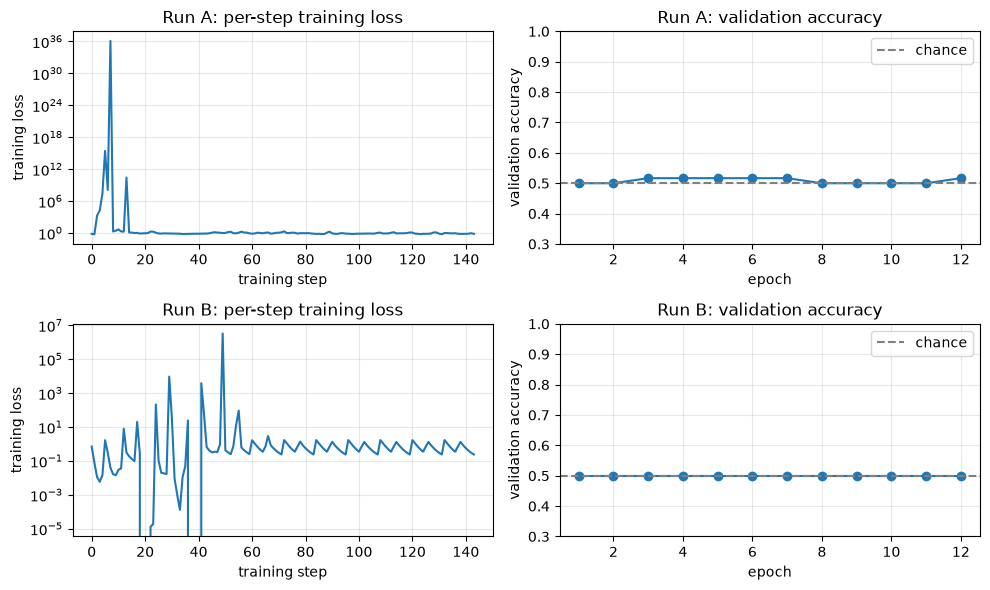

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for row, (name, res) in enumerate(broken.items()):
    ax = axes[row, 0]
    ax.semilogy(res["step_loss"])
    ax.set_xlabel("training step")
    ax.set_ylabel("training loss")
    ax.set_title(f"{name}: per-step training loss")
    ax.grid(alpha=0.3)
    ax = axes[row, 1]
    ax.plot(np.arange(1, len(res["val_acc"]) + 1), res["val_acc"], marker="o")
    ax.axhline(0.5, color="gray", ls="--", label="chance")
    ax.set_ylim(0.3, 1.0)
    ax.set_xlabel("epoch")
    ax.set_ylabel("validation accuracy")
    ax.set_title(f"{name}: validation accuracy")
    ax.legend()
    ax.grid(alpha=0.3)
    print(f"{name}: final model calls {res['frac_event']:.0%} of validation windows an event")
plt.tight_layout()

<!-- answer -->
**Exécution A**
* Pathologie :
* Preuve :
* Correctif :

**Exécution B**
* Pathologie :
* Preuve :
* Correctif :

## 4. Une évaluation honnête (15 points)

Le score d'un détecteur ne signifie rien en lui-même. Nous établissons ce qu'obtiennent un modèle trivial et un modèle linéaire sur le même découpage, nous auditons la chaîne de traitement à la recherche de fuites de données, et nous rapportons chaque métrique avec son incertitude — le dispositif de la leçon 4.5 et les règles de classement de 3.5 et 4.10.

* les références d'abord (4 points)
* audit de fuite de données (3 points)
* métriques avec incertitude (6 points)
* verdict (2 points)

### 4.1 Les références d'abord

**Tâche : calculez deux références sur l'ensemble de test (4 points) :** la référence de la classe majoritaire, et une ``LogisticRegression(max_iter=5000)`` entraînée sur les mêmes spectres standardisés (``X_train``). Rapportez les deux exactitudes de test.

In [13]:
# TODO: majority-class baseline and logistic-regression baseline on the test set

### 4.2 Audit de fuite de données

**Tâche : répondez en trois phrases (3 points).** (1) Pourquoi le ``StandardScaler`` doit-il être ajusté sur le seul ensemble d'entraînement — qu'est-ce qui fuit exactement s'il est ajusté sur le jeu de données complet avant le découpage ? (2) Pourquoi la transformation en spectre, fenêtre par fenêtre (la cellule ``X_spec``), peut-elle sans risque être appliquée avant le découpage ? (3) Nommez une décision que vous avez prise dans ce carnet en vous appuyant sur l'ensemble de validation, et confirmez que l'ensemble de test n'y a joué aucun rôle.

<!-- answer -->

### 4.3 Métriques avec incertitude

Un ensemble de test de 240 fenêtres est un échantillon, pas la vérité ; la fonction utilitaire ci-dessous le rééchantillonne par *bootstrap* (rééchantillonnage avec remise) pour poser un intervalle de confiance sur une exactitude.

**Tâche : rapportez l'exactitude de test avec un intervalle de confiance *bootstrap* à 95 % pour votre MLP entraîné à la section 1 et pour la référence par régression logistique (6 points).**

In [14]:
def bootstrap_ci(y_true, y_pred, n_boot=2000, seed=0):
    """95% bootstrap confidence interval for accuracy."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    accs = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        accs[b] = np.mean(y_true[idx] == y_pred[idx])
    return np.percentile(accs, [2.5, 97.5])

In [15]:
# TODO: test accuracy with 95% CI, MLP and logistic baseline

### 4.4 Verdict

**Tâche : dites si le MLP bat la référence logistique, en vous appuyant sur les intervalles de confiance, et expliquez le résultat en une ou deux phrases (2 points).** Si les intervalles se recouvrent, dites-le franchement — la règle de la leçon 4.5 s'applique : si votre modèle profond ne peut pas battre la référence linéaire, le problème est dans les données ou les caractéristiques, pas dans une couche manquante. Qu'est-ce qui, dans cette représentation, rend un modèle linéaire si compétitif, et vers quel modèle du chapitre 4 vous tourneriez-vous pour faire mieux sur les formes d'onde brutes ?

<!-- answer -->

## 5. L'incertitude par un petit ensemble profond (12 points)

```{admonition} 🤝 Assistant autorisé
:class: tip
Utilisez votre assistant si vous le souhaitez — vérifiez chaque ligne et déclarez cet usage dans votre rendu ([1.8](../Chapter1-GettingStarted/1.8_ai_in_your_workflow.md)).
```

Réentraîner la même architecture avec des graines différentes donne un ensemble profond (leçon 4.5, pilier 2) : les membres s'accordent là où les données parlent clairement et divergent là où elles ne le font pas.

* entraîner 3 membres (4 points)
* dispersion en fonction de l'erreur (5 points)
* énoncé de calibration (3 points)

### 5.1 Entraîner trois membres

**Tâche : entraînez trois modèles ``width=32`` avec les graines 100, 101 et 102 — mêmes données, mêmes hyperparamètres qu'à la section 1 — et collectez pour chaque membre la probabilité prédite d'« événement » sur l'ensemble de test (4 points).** Empilez-les dans un tableau ``member_probs`` de forme ``(3, n_test)`` (appliquez le softmax aux *logits* et gardez la colonne 1).

In [16]:
# TODO: three members, member_probs of shape (3, n_test)

### 5.2 Dispersion en fonction de l'erreur

**Tâche : rapportez l'exactitude de la prédiction moyenne de l'ensemble, puis appelez ``plot_spread_vs_error(member_probs, y_test)`` et décrivez le motif en une phrase (5 points).** La fonction utilitaire répartit les fenêtres de test en terciles de dispersion de l'ensemble (l'écart-type des trois probabilités prédites) et trace l'exactitude dans chaque tercile.

In [17]:
def plot_spread_vs_error(member_probs, y_true):
    """Accuracy within terciles of ensemble spread."""
    P = np.asarray(member_probs)
    mean_p, std_p = P.mean(axis=0), P.std(axis=0)
    correct = (mean_p > 0.5).astype(int) == np.asarray(y_true)
    edges = np.quantile(std_p, [0, 1/3, 2/3, 1.0])
    edges[-1] += 1e-9
    labels = ["low spread", "medium spread", "high spread"]
    accs = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = (std_p >= lo) & (std_p < hi)
        accs.append(correct[in_bin].mean())
    fig, ax = plt.subplots(figsize=(5.5, 3.5))
    ax.bar(labels, accs, edgecolor="black")
    ax.axhline(correct.mean(), color="black", ls="--",
               label=f"overall accuracy {correct.mean():.2f}")
    ax.set_ylabel("accuracy in bin")
    ax.set_ylim(0.4, 1.0)
    ax.set_title("Ensemble spread vs error")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    return accs

In [18]:
# TODO: ensemble-mean accuracy, then plot_spread_vs_error(member_probs, y_test)

<!-- answer -->

### 5.3 Énoncé de calibration

**Tâche : comparez la confiance moyenne de l'ensemble à son exactitude et écrivez une phrase de calibration (3 points).** Calculez la confiance de chaque prédiction de test (la plus grande valeur entre ``mean_p`` et ``1 - mean_p``), moyennez-la sur l'ensemble de test, et placez-la à côté de l'exactitude de l'ensemble obtenue en 5.2. Votre phrase doit nommer le sens et l'ordre de grandeur de l'erreur de calibration — par exemple : « l'ensemble revendique X % de confiance mais a raison Y % du temps, il est donc trop confiant d'environ Z points ».

In [19]:
# TODO: mean confidence vs accuracy

<!-- answer -->

## 6. Déclaration d'usage de l'IA (3 points)

Chaque rendu de ce cours porte une déclaration ([1.8](../Chapter1-GettingStarted/1.8_ai_in_your_workflow.md), [6.4](../Chapter6-AgenticAI/6.4_disclosure_and_norms.md)). Remplissez le tableau : une ligne par outil, indiquant la tâche qu'il a effectuée et ce que vous avez vérifié. C'est la troisième colonne qui est notée — « rien vérifié » est au moins honnête et coûte moins cher qu'une affirmation de vérification qui s'effondre à la première question. Si vous n'avez employé aucun assistant, écrivez une ligne le disant. Rappelez-vous que la boucle d'entraînement de 1.4 et les diagnostics de la section 3 étaient 🔒 À la main : ils ne doivent pas figurer ici comme tâches d'assistant, et il pourra vous être demandé de les défendre à l'oral.

**Tâche : complétez le tableau de déclaration (3 points).**

| Outil | Tâche | Ce que j'ai vérifié |
|---|---|---|
| | | |
| | | |

```{admonition} Notes de correction pour l'enseignante
:class: dropdown

Les valeurs de référence ci-dessous proviennent de la solution de référence (données à graine 2026, 25 époques, Adam ``lr=1e-3``, lot de 64). Les choix d'implémentation (générateur aléatoire du brassage, type des tenseurs) déplacent les exactitudes de 1 à 2 points ; notez le raisonnement, et servez-vous de la variante à graine cachée pour contrôler par sondage tout résultat qui semble recopié plutôt qu'exécuté.

**1. MLP (20 pts).** 1.1 (2) : effectifs 600/600 ; forme d'onde d'événement avec P et S marqués, spectres montrant une bosse à bande limitée face à un bruit en loi de puissance. 1.2 (4) : découpage 60/20/20 stratifié ; le plein crédit exige un *scaler* ajusté sur ``X_train`` seulement — un ajustement sur les données complètes fait perdre 2 points. 1.3 (4) : deux couches cachées de taille ``width`` avec ReLU, tête linéaire, pas de softmax dans ``forward`` (softmax dans forward : −1). 1.4 (8) : 🔒 à la main. Cherchez : une permutation neuve à chaque époque (2), l'ordre correct zero_grad/backward/step (2), la validation en ``eval()`` + ``no_grad`` puis retour en ``train()`` (2), l'historique enregistré par époque et les graines fixées (2). Une boucle avec ``DataLoader`` est acceptable. 1.5 (2) : les courbes plus une phrase étayée — attendu : un écart léger, « ni l'un ni l'autre » comme « léger surapprentissage » se défendent.

**2. Expérience de largeur (15 pts).** 2.1 (8) : neuf exécutions, exactitude de validation finale pour chacune ; moyennes de référence ≈ 0,81 (w=8), 0,83 (w=32), 0,85 (w=128) avec une dispersion sur les graines ≈ ±0,01–0,02. 2.2 (4) : moyenne avec barres min-max, axe des abscisses logarithmique. 2.3 (3) : toute largeur est acceptable si l'argument compare les écarts à la dispersion et mentionne le coût en paramètres ; « 128 parce que c'est le plus grand nombre » sans la comparaison à la dispersion vaut 1 point.

**3. Exécutions défaillantes (10 pts, 🔒 à la main).**
*Exécution A — taux d'apprentissage trop élevé* (SGD, ``lr=5.0``). Preuve : la perte par pas explose jusqu'à ~1e36 dès les premières époques et continue de faire des pics sur l'axe logarithmique ; l'exactitude de validation reste au niveau du hasard sur les 12 époques ; le modèle final déclare « événement » ~3 % des fenêtres de validation. Correctif : diviser le taux d'apprentissage par 10 à 100 (ou passer à Adam à 1e-3).
*Exécution B — lots non brassés et triés par classe* (``ordered=True`` : tous les lots de bruit, puis tous les lots d'événements, dans un ordre identique à chaque époque). Preuve : l'exactitude de validation reste bloquée à exactement 0,50 sur les 12 époques alors que la perte d'entraînement par pas paraît saine (~0,4–0,7) et répète une dent de scie identique à chaque époque ; la ligne affichée montre que le modèle final déclare « événement » 100 % des fenêtres de validation — il bascule vers la dernière classe qu'il a vue. Correctif : brasser les données d'entraînement à chaque époque.
Par exécution : pathologie 2, preuve 2, correctif 1. Acceptez les formulations « données ordonnées par classe / absence de brassage » ; « surapprentissage » pour l'exécution B vaut 0 pour le point de pathologie.

**4. Évaluation honnête (15 pts).** 4.1 (4) : référence majoritaire 0,50 ; régression logistique ≈ 0,85 d'exactitude de test. 4.2 (3) : un point par phrase — (1) un *scaler* ajusté sur les données complètes fait fuiter les moyennes et variances de l'ensemble de test dans les entrées d'entraînement ; (2) le spectre est calculé par fenêtre à partir de cette seule fenêtre, aucune statistique inter-fenêtres ne circule donc ; (3) le choix de la largeur n'a utilisé que la validation. 4.3 (6) : MLP ≈ 0,83 [0,78, 0,88], logistique ≈ 0,85 [0,81, 0,90] — demi-largeur d'IC ≈ ±0,045. 4.4 (2) : verdict attendu — les intervalles se recouvrent ; le MLP ne bat **pas** la référence linéaire. La représentation en log-spectre linéarise presque le problème (l'amplitude spectrale logarithmique face à la classe est proche de la séparabilité linéaire) ; le modèle vers lequel se tourner sur les formes d'onde brutes est le CNN 1-D de la leçon 4.3. Sanctionnez les affirmations de supériorité du MLP fondées sur des estimations ponctuelles que les IC contredisent.

**5. Ensemble (12 pts).** 5.1 (4) : graines 100/101/102, exactitudes de test des membres ≈ 0,82–0,85. 5.2 (5) : exactitude de la moyenne d'ensemble ≈ 0,83 ; exactitudes par tercile ≈ 0,96 / 0,85 / 0,69 — décroissance monotone, c'est-à-dire que la dispersion classe bien les erreurs. 5.3 (3) : confiance moyenne ≈ 0,87 face à une exactitude ≈ 0,83 → trop confiant d'environ 4 points ; la phrase doit énoncer le sens et l'amplitude, pas seulement « raisonnablement calibré ».

**6. Déclaration (3 pts).** Notée selon 6.4 : des tâches précises et une vérification concrète valent 3 ; une déclaration vide ou générique (« j'ai vérifié que ça a l'air correct ») vaut 1 ; une déclaration qui liste des sections 🔒 comme travail d'assistant déclenche la défense orale.
```